In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

In [12]:
!pip install -q --upgrade \
    "protobuf>=6.31.1" \
    tensorflow-metadata \
    tensorflow-datasets

In [14]:
import google.protobuf

print("Protobuf:", google.protobuf.__version__)

Protobuf: 5.29.6


In [15]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [17]:
!pip install -q --upgrade \
    "protobuf==6.31.1" \
    "tensorflow-datasets==4.9.10" \
    tensorflow-metadata

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import google.protobuf

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("Protobuf:", google.protobuf.__version__)

/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

TensorFlow: 2.20.0
TFDS: 4.9.10
Protobuf: 6.31.1


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DATA_DIR = "/content/drive/MyDrive/malaria_cnn_project/tfds_data"

In [4]:
(train_dataset,
 val_dataset,
 test_dataset), dataset_info = tfds.load(

    "malaria",

    split=[
        "train[:80%]",
        "train[80%:90%]",
        "train[90%:]"
    ],

    shuffle_files=True,
    with_info=True,

    data_dir=DATA_DIR
)

In [5]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 22046
Validation: 2756
Test: 2756


In [6]:
for sample in train_dataset.take(1):

    print(sample["image"].shape)
    print(sample["label"])

(151, 115, 3)
tf.Tensor(1, shape=(), dtype=int64)


In [7]:
for sample in train_dataset.take(1):

    label = sample["label"]

    print("Tensor label:", label)
    print("Number label:", label.numpy())

Tensor label: tf.Tensor(1, shape=(), dtype=int64)
Number label: 1


In [8]:
def get_label_string(label):

    if label == 0:
        return "parasitized"

    else:
        return "uninfected"

In [9]:
print(get_label_string(0))
print(get_label_string(1))

parasitized
uninfected


1
uninfected


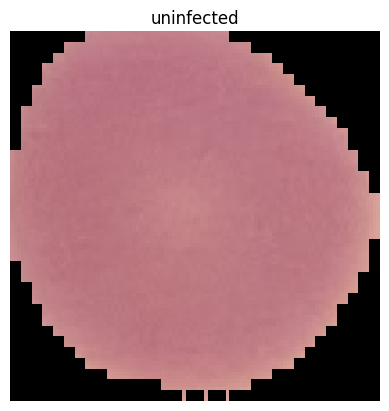

In [11]:
for sample in train_dataset.take(1):

    image = sample["image"]
    label = sample["label"].numpy()
    plt.imshow(image)
    print(label)
    print(get_label_string(label))
    plt.title(
        get_label_string(label)
    )

    plt.axis("off")
    plt.show()

# visualize 9 samples

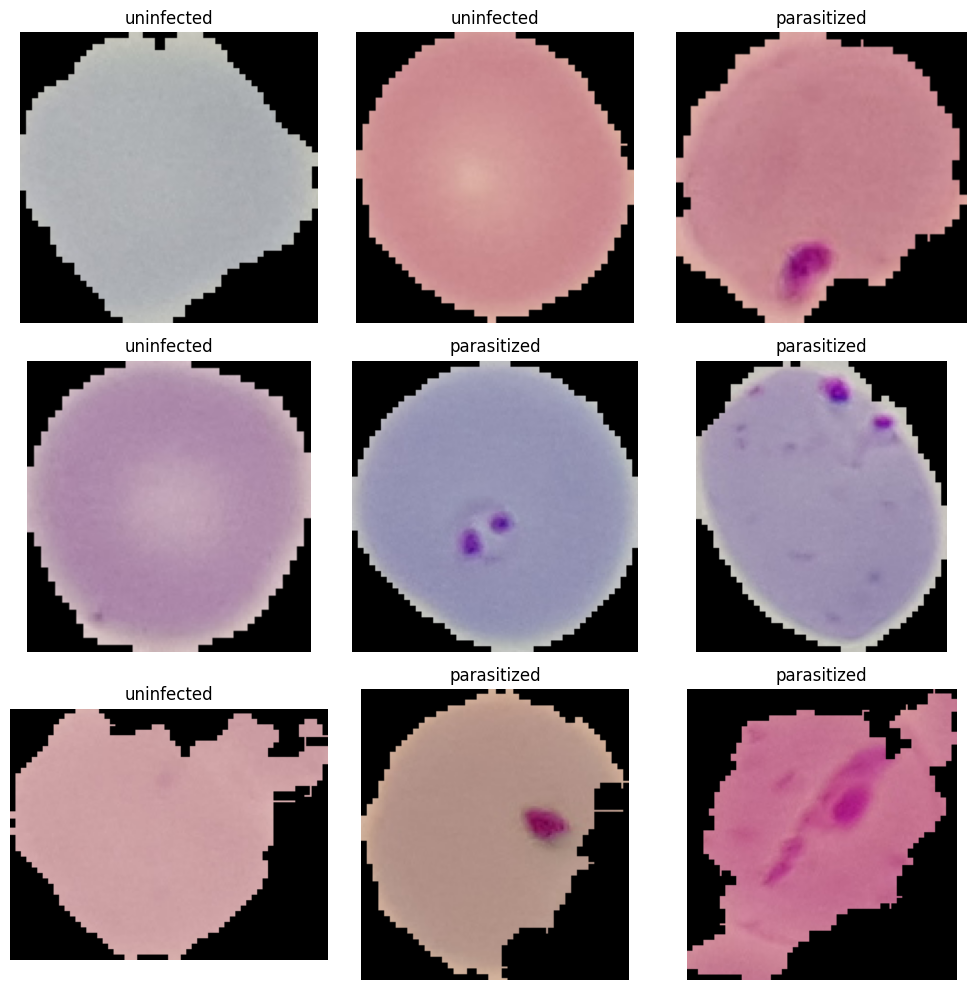

In [13]:
plt.figure(figsize=(10, 10))

for i, sample in enumerate(train_dataset.take(9)):

    image = sample["image"]
    label = sample["label"].numpy()

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(
        get_label_string(label)
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

আর subplot না দিলে:

plt.imshow(image)

প্রতিবার একই plotting area-তে image draw করার চেষ্টা করবে; তুমি clean 3×3 arrangement পাবে না।